<a href="https://colab.research.google.com/github/bahenaj36-create/Fenomenos-Bioelectricos/blob/main/Espectro_Fourier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad: archivo EDF y espectro de Fourier**
### LecturadelEEG, selecciondecanal, segmentacion,FFT y generacion de una imagen del espectro.
Joshua Bahena #2018505

Por favor, sube tu archivo .edf...


Saving Subject00_2.edf to Subject00_2 (2).edf

--- METADATOS DEL EEG ---
Frecuencia de muestreo (fs): 500.0 Hz
Número de canales: 21
Primeros canales: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4']

Usando el canal detectado: EEG O1


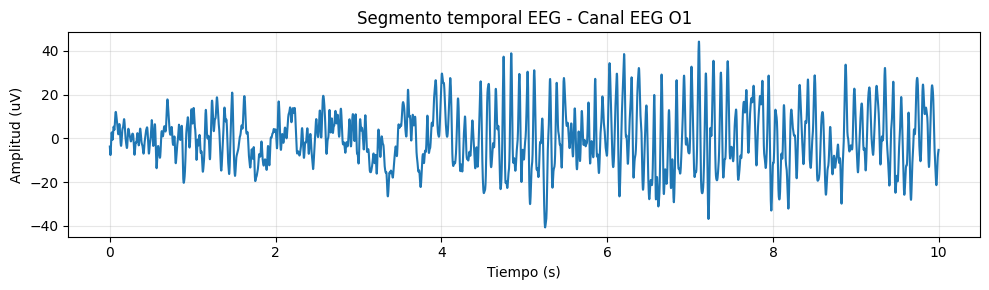

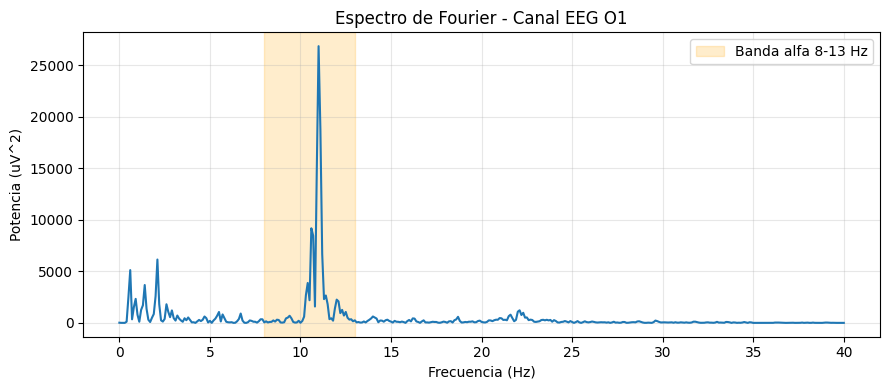


¡Análisis completado! La imagen ha sido guardada como 'espectro_fourier_eeg.png'


In [4]:
# ==========================================
# FASE 1: INSTALACIÓN E IMPORTACIÓN
# ==========================================
# Instalar la librería MNE silenciosamente
!pip -q install mne

import numpy as np
import matplotlib.pyplot as plt
import mne
from google.colab import files

# ==========================================
# FASE 2: CARGA DEL ARCHIVO EDF
# ==========================================
print("Por favor, sube tu archivo .edf...")
uploaded = files.upload() # Esto abrirá una ventana para cargar tu archivo

# Obtener automáticamente el nombre del archivo subido
edf_path = list(uploaded.keys())[0]

# Leer el archivo con MNE
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

# ==========================================
# FASE 3: EXPLORACIÓN DEL REGISTRO
# ==========================================
print("\n--- METADATOS DEL EEG ---")
fs = raw.info["sfreq"]
print("Frecuencia de muestreo (fs):", fs, "Hz")
print("Número de canales:", len(raw.ch_names))
print("Primeros canales:", raw.ch_names[:10])

# ==========================================
# FASE 4: EXTRACCIÓN DEL SEGMENTO TEMPORAL
# ==========================================
# Ajustamos el nombre del canal para que coincida con el formato del archivo (ej. 'EEG O1')
canal_objetivo = "O1"
canal = [ch for ch in raw.ch_names if canal_objetivo in ch][0]
print(f"\nUsando el canal detectado: {canal}")

inicio = 0   # Segundos
duracion = 10 # Segundos

# Extraer los datos del canal seleccionado
raw_pick = raw.copy().pick([canal])
datos, tiempos = raw_pick.get_data(
    start=int(inicio * fs),
    stop=int((inicio + duracion) * fs),
    return_times=True
)

senal = datos[0] * 1e6 # Convertir a microvoltios (uV)

# Graficar la señal en el dominio del tiempo
plt.figure(figsize=(10,3))
plt.plot(tiempos, senal)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (uV)")
plt.title(f"Segmento temporal EEG - Canal {canal}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# FASE 5: PREPARACIÓN Y CÁLCULO DE LA FFT
# ==========================================
# Centrar la señal (eliminar componente DC)
senal_centrada = senal - np.mean(senal)

# Aplicar ventana de Hann
ventana = np.hanning(len(senal_centrada))
senal_ventaneada = senal_centrada * ventana

# Calcular la FFT
N = len(senal_ventaneada)
freqs = np.fft.rfftfreq(N, d=1/fs) # Vector de frecuencias
fft_vals = np.fft.rfft(senal_ventaneada)

# Calcular magnitud y potencia
magnitud = np.abs(fft_vals)
potencia = (magnitud ** 2) / N

# ==========================================
# FASE 6: GRAFICAR Y GUARDAR EL ESPECTRO
# ==========================================
# Crear máscara para limitar el gráfico a 0-40 Hz
mask = (freqs >= 0) & (freqs <= 40)

plt.figure(figsize=(9,4))
plt.plot(freqs[mask], potencia[mask])
plt.axvspan(8, 13, color='orange', alpha=0.2, label="Banda alfa 8-13 Hz")

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia (uV^2)")
plt.title(f"Espectro de Fourier - Canal {canal}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Guardar y mostrar
nombre_imagen = "espectro_fourier_eeg.png"
plt.savefig(nombre_imagen, dpi=200)
plt.show()

print(f"\n¡Análisis completado! La imagen ha sido guardada como '{nombre_imagen}'")

## Preguntas

1. **¿Qué archivo EDF analizaste?**
   Analicé el archivo `Subject00_2.edf`.

2. **¿Qué canal EEG seleccionaste?**
   Seleccioné el canal `EEG O1`.

3. **¿Cuál fue la frecuencia de muestreo del registro?**
   La frecuencia de muestreo fue de `500.0 Hz`.

4. **¿Qué duración tuvo el segmento temporal analizado?**
   El segmento analizado tuvo una duración de `10 segundos`.

5. **¿En qué frecuencia aparece el pico principal del espectro?**
   El pico principal aparece aproximadamente a los `10 Hz`.

6. **¿A qué banda EEG pertenece ese pico?**
   Pertenece a la banda Alfa (8-13 Hz).

7. **¿La gráfica temporal permitía identificar visualmente esa frecuencia?**
   Es difícil identificarla con precisión solo con la vista; aunque se ven oscilaciones, la FFT es necesaria para confirmar la frecuencia exacta.

8. **¿Qué limitaciones tiene interpretar sola una FFT sin revisar artefactos?**
   La FFT puede interpretar erróneamente movimientos o parpadeos como actividad cerebral real, y no muestra cómo varía la señal en el tiempo (estacionariedad).